In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


final_speed = 20.
num_cores = 200
maxtime = 1440
runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
#runID = "Fasymp20_fixgaussian20_50GW" # _nG30"

student = "JadonsSolution"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

#filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
#filepath = "combine_extract.ipynb"
filepath = r"C:\\Users\\rosew\\relativistic-lightsail-dynamics\\Optimisation"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Combining" / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 7171191
Average function evaluations per core: 35855


In [2]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [3]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 4

# wavelength_range = [1,1/D1_ND([final_speed/100,0])]
wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[0.99988599895999, 1.00010440104001]
Total function evaluations: 7171191
Average function evaluations per core: 35855
TORCWA
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]
[tensor(1.5890, dtype=torch.float64), tensor(0.6815, dtype=torch.float64), tensor(1.1635, dtype=torch.float64), tensor(1.2270, dtype=torch.float64), tensor(0.4843, dtype=torch.float64), tensor(12.2500, dtype=torch.float64), tensor(8.4398, dtype=torch.float64), tensor(1.8405, dtype=torch.float64), tensor(7.7248, dtype=torch.float64)]


c:\Users\rosew\AppData\Local\Programs\Python\Python312\Lib\site-packages\torcwa\rcwa.py:62: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  self.L = torch.as_tensor(L,dtype=self._dtype,device=self._device)


0.014213230597554142
grating_pitch   = 1.588999104221404
grating_depth   = 0.6814547486670015
box1_width      = 1.1635183838602672
box2_width      = 1.2269988733783472
box_centre_dist = 0.4843187147417837
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0
substrate_depth = 1.8404998380763957
substrate_eps   = 7.724841176163067

FoM recorded:     0.014213230598221122


In [6]:
scaled = 1.000025 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"\nFoM at scaled wavelength: {actual_fom}")

grating_pitch   = 1.5890388291990094
grating_depth   = 0.6814717850357181
box1_width      = 1.1635474718198635
box2_width      = 1.2270295483501816
box_centre_dist = 0.48433082270965216
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0005
substrate_depth = 1.8405458505723475
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.014211517059641113


In [5]:
calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)
for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

FoM at scaled wavelength 0.01: -305.888768005491
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
FoM at scaled wavelength 0.012387136088955098: -295.18199769046
FoM at scaled wavelength 0.013068135717693687: -291.8189612852468
FoM at scaled wavelength 0.013786574225848126: -288.1388259688763
FoM at scaled wavelength 0.01454450986665786: -284.1199895766255
FoM at scaled wavelength 0.015344114048629382: -279.7412859230197
FoM at scaled wavelength 0.016187677556400663: -274.98250434121843
FoM at scaled wavelength 0.017077617113606152: -269.8250032740369
FoM at scaled wavelength 0.01801648230654411: -264.25241324641877
FoM at scaled wavelength 0.019006962888481985: -258.2514215973263
FoM at scaled wavelength 0.020051896485525914: -251.81261605429725
FoM at scaled wavelength 0.021154276726130787: -244.93136183039687
FoM at scaled wavelength 0.

In [7]:
import matplotlib.pyplot as plt
plt.clf()
plt.semilogx(scales, calc_foms, label='Calculated FoM at scaled wavelength')

plt.plot(scales, np.zeros_like(scales)+actual_fom, 'k--', label='Original FoM of Jadon Solution')
plt.xlabel('Scaled wavelength')
plt.ylabel('Figure of Merit (FoM)')
plt.title('FoM vs Scaled Wavelength for Optimised Grating')
plt.legend()

NameError: name 'scales' is not defined

<Figure size 1500x750 with 0 Axes>

In [5]:
scaled = scales[np.argmax(calc_foms)]

scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")

NameError: name 'scales' is not defined

[0.17053559 0.17057284]


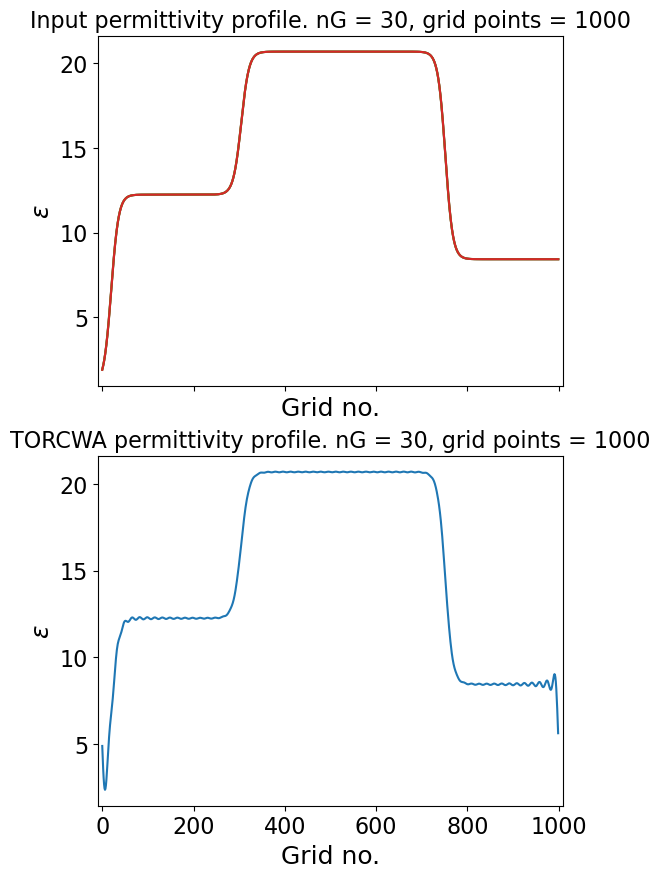

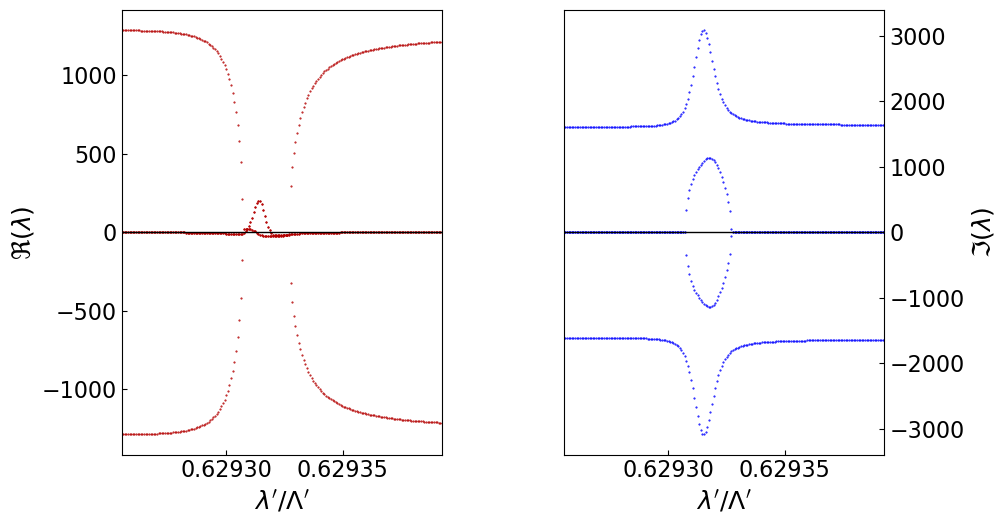

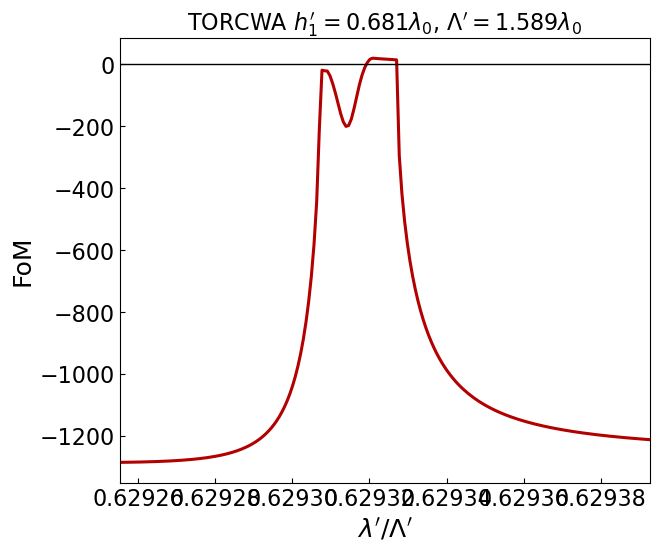

In [9]:
angle = 0.
n_plot = 200

wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]


wavelength_range = np.array(wavelength_range) * scaled
print(wavelength_range)

# _, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True, show_box_edges=False)
_, _, p_fig, p_ax = scaled_grating.show_permittivity(show_analytic_box=True)
eig_fig, eig_ax = scaled_grating.show_Eigs(wavelength_range, I0, n_plot, False, False, 'o')
spec_fig, spec_ax = scaled_grating.show_FOM_spectrum(angle=angle, wavelength_range=wavelength_range, num_plot_points=n_plot, I=I0)

save_fname = fname_preamble / "scaled" /  f"opt{optimum_number}"
save_fname.mkdir(parents=True, exist_ok=True)
p_fig.savefig(save_fname / f"opt{optimum_number}_permittivity.pdf", bbox_inches = "tight")
eig_fig.savefig(save_fname / f"opt{optimum_number}_eigvals.pdf", bbox_inches = "tight")
spec_fig.savefig(save_fname / f"opt{optimum_number}_F_lam_spectrum.pdf", bbox_inches = "tight")

[0.99988599895999, 1.00010440104001]


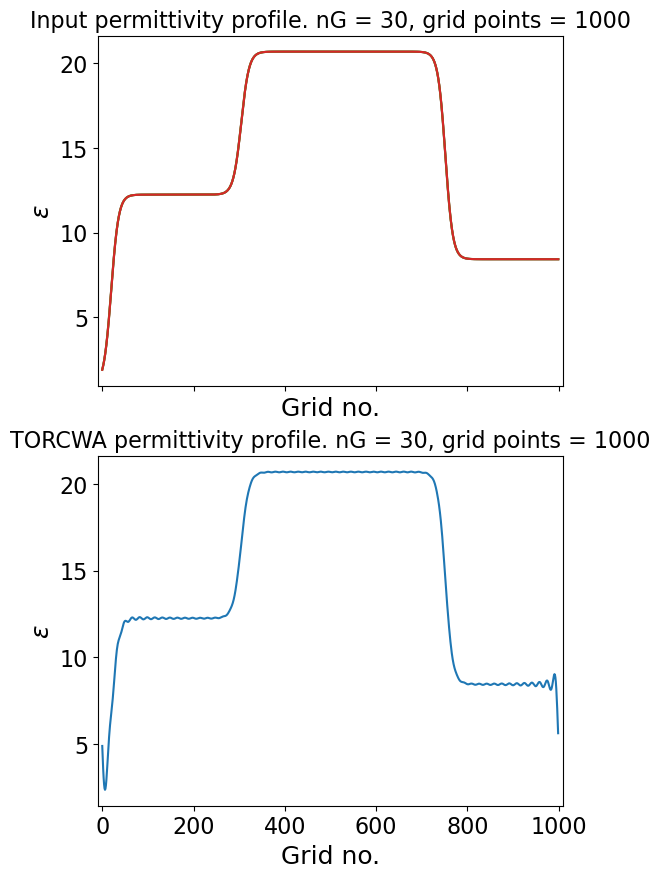

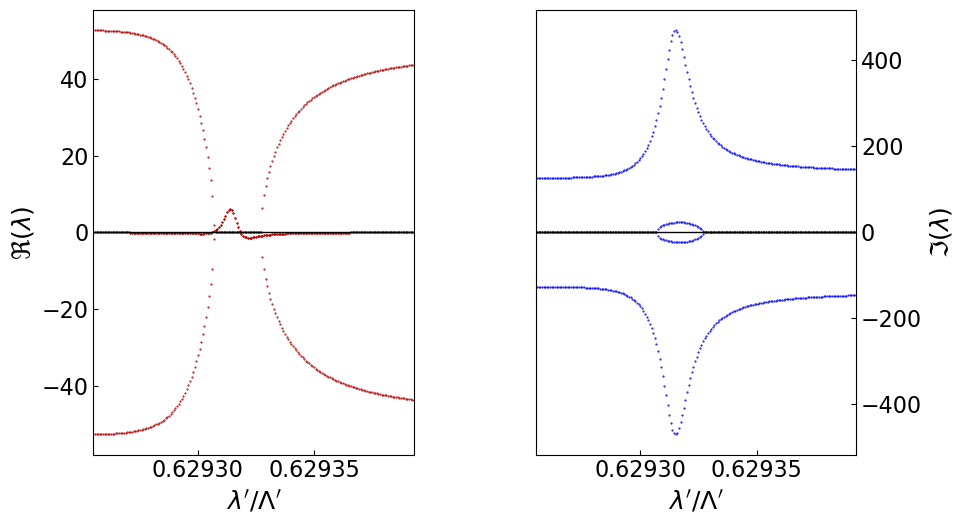

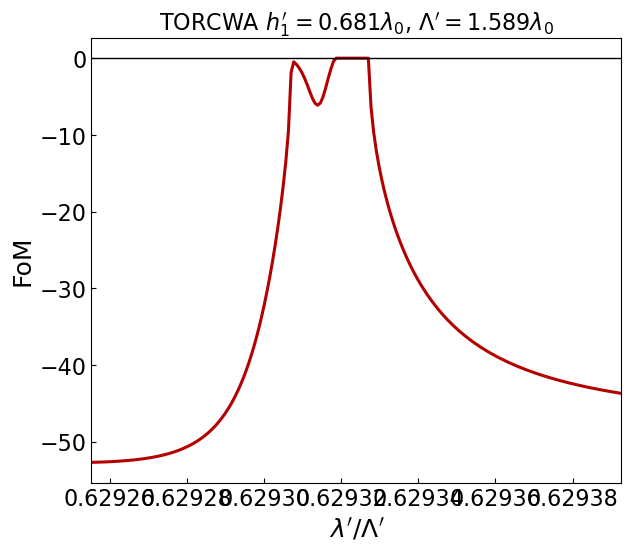

In [10]:
angle = 0.
n_plot = 200

wavelength_range = [0.99999,1.0000004]
bandwidth = wavelength_range[1] - wavelength_range[0]
relative_bandwidth = bandwidth / wavelength_range[0]
wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)

# _, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True, show_box_edges=False)
_, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True)
eig_fig, eig_ax = grating.show_Eigs(wavelength_range, I0, n_plot, False, False, 'o')
spec_fig, spec_ax = grating.show_FOM_spectrum(angle=angle, wavelength_range=wavelength_range, num_plot_points=n_plot, I=I0)

save_fname = fname_preamble / "original" /  f"opt{optimum_number}"
save_fname.mkdir(parents=True, exist_ok=True)
p_fig.savefig(save_fname / f"opt{optimum_number}_permittivity.pdf", bbox_inches = "tight")
eig_fig.savefig(save_fname / f"opt{optimum_number}_eigvals.pdf", bbox_inches = "tight")
spec_fig.savefig(save_fname / f"opt{optimum_number}_F_lam_spectrum.pdf", bbox_inches = "tight")

In [8]:
stiffnesses_original = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix
stiffnesses_scaled = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False)

J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_original))
J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_scaled))


eigReal_o, eigImag_o = fom.Eigs(grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

eigReal_s, eigImag_s = fom.Eigs(scaled_grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

# i think just replace grating with the grating needed (scaled or original)

In [16]:
avg_J = 0.5 * (J_original + J_scaled)

In [26]:
import torch
eigs_avgJ = torch.linalg.eigvals(avg_J).real
print(eigs_avgJ)

tensor([-0.5452, -0.5452, -0.0074, -0.0074], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [7]:
avg_of_eigs_real = 0.5 * (eigReal_o + eigReal_s)

In [8]:
print(avg_of_eigs_real)

tensor([-0.5452, -0.5452, -0.0074, -0.0074], dtype=torch.float64,
       grad_fn=<MulBackward0>)


In [22]:
eigvals, eigvecs = scaled_grating.npa.eig(J_scaled)
eigReal_s_testing = scaled_grating.npa.real(eigvals)
print(eigReal_s_testing)

tensor([-0.1285, -0.1285, -0.0005, -0.0005], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [18]:
eigvals, eigvecs = grating.npa.eig(J_original)
eigReal_o_testing = grating.npa.real(eigvals)
print(eigReal_o_testing)

tensor([-0.9619, -0.9619, -0.0142, -0.0142], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [11]:
print(eigReal_o)

tensor([-0.9619, -0.9619, -0.0142, -0.0142], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [ ]:
#THERE ARE NO DIFFERENCES BETWEEN THE METHODS OF FINDING EIGS FOR ORIGINAL OR SCALED
import torch
eig_real_o_testing_torchway = torch.linalg.eigvals(J_original).real
print(eig_real_o_testing_torchway - eigReal_o_testing)
print(eigReal_o_testing - eigReal_o)

tensor([0., 0., 0., 0.], dtype=torch.float64, grad_fn=<SubBackward0>)
tensor([0., 0., 0., 0.], dtype=torch.float64, grad_fn=<SubBackward0>)


In [24]:
eig_real_s_testing_torchway = torch.linalg.eigvals(J_scaled).real
print(eig_real_s_testing_torchway - eigReal_s_testing)
print(eigReal_s_testing - eigReal_s)

print(eigReal_s)

tensor([0., 0., 0., 0.], dtype=torch.float64, grad_fn=<SubBackward0>)
tensor([0., 0., 0., 0.], dtype=torch.float64, grad_fn=<SubBackward0>)
tensor([-0.1285, -0.1285, -0.0005, -0.0005], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [28]:
#Finding differences between average of eigs and eigs of average matrix 

difference = eigs_avgJ - avg_of_eigs_real

print("The absolute difference is ", difference)
print("The difference (relative to eigs of avg matrix) is", difference/eigs_avgJ)

The absolute difference is  tensor([-1.4512e-08, -1.4512e-08,  1.4512e-08,  1.4512e-08],
       dtype=torch.float64, grad_fn=<SubBackward0>)
The difference (relative to eigs of avg matrix) is tensor([ 2.6618e-08,  2.6618e-08, -1.9732e-06, -1.9732e-06],
       dtype=torch.float64, grad_fn=<DivBackward0>)


Performing analysis again - scaling just the grating parameters and NOT the wavelength (to see if it gets worse with adjacent wavelength)

In [29]:
scaled = 1.000025 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating_NOT_wavelength = TwoBox(*scaled_opt_params, wavelength=1., angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom_NOT_scaling_wavelength = fom.multifom(scaled_grating_NOT_wavelength, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating_NOT_wavelength)
print(f"\nFoM at scaled wavelength: {actual_fom}")
print(f"\nFoM at unscaled wavelength: {actual_fom_NOT_scaling_wavelength}")

grating_pitch   = 1.5890388291990094
grating_depth   = 0.6814717850357181
box1_width      = 1.1635474718198635
box2_width      = 1.2270295483501816
box_centre_dist = 0.48433082270965216
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 20.0005
substrate_depth = 1.8405458505723475
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.014211517059641113

FoM at unscaled wavelength: -3.4911344847983337


In [30]:
stiffnesses_scaled_NOT_wavelength = fom.force_coeff(scaled_grating_NOT_wavelength,I0,m,c,grad_method="finite",out="mat",normalise=False)

J_scaled_NOT_wavelength = scaled_grating_NOT_wavelength.npa.concatenate((scaled_grating_NOT_wavelength.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_scaled_NOT_wavelength))

eigReal_s_notwave, eigImag_s_notwave = fom.Eigs(scaled_grating_NOT_wavelength,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

# i think just replace grating with the grating needed (scaled or original)

In [31]:
avg_J_notwave = 0.5 * (J_original + J_scaled_NOT_wavelength)
eigs_avgJ_notwave = torch.linalg.eigvals(avg_J_notwave).real
print(eigs_avgJ_notwave)

tensor([1.2549, 1.2549, 0.0096, 0.0096], dtype=torch.float64,
       grad_fn=<SelectBackward0>)


In [32]:
avg_of_eigs_real_notwave = 0.5 * (eigReal_o + eigReal_s_notwave)
print(avg_of_eigs_real_notwave)

tensor([ 1.2651e+00,  1.2651e+00, -5.8387e-04, -5.8387e-04],
       dtype=torch.float64, grad_fn=<MulBackward0>)


In [33]:
difference_notwave = eigs_avgJ_notwave - avg_of_eigs_real_notwave

print("The absolute difference is ", difference_notwave)
print("The difference (relative to eigs of avg matrix) is", difference_notwave/eigs_avgJ_notwave)

The absolute difference is  tensor([-0.0102, -0.0102,  0.0102,  0.0102], dtype=torch.float64,
       grad_fn=<SubBackward0>)
The difference (relative to eigs of avg matrix) is tensor([-0.0081, -0.0081,  1.0606,  1.0606], dtype=torch.float64,
       grad_fn=<DivBackward0>)


In [14]:
scaled2 = 1.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled2 * scaled_opt_params[p]
    
scaled_grating2 = TwoBox(*scaled_opt_params, wavelength=scaled2, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom2 = fom.multifom(scaled_grating2, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating2)
print(f"\nFoM at scaled wavelength: {actual_fom2}")

grating_pitch   = 1.6684490594324743
grating_depth   = 0.7155274861003517
box1_width      = 1.2216943030532805
box2_width      = 1.2883488170472646
box_centre_dist = 0.5085346504788729
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 21.0
substrate_depth = 1.9325248299802156
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: 0.011230349643794537


In [43]:
stiffnesses_original = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix
stiffnesses_scaled2 = fom.force_coeff(scaled_grating2,I0,m,c,grad_method="finite",out="mat",normalise=False)

J_scaled2 = scaled_grating2.npa.concatenate((scaled_grating2.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_scaled2))


eigReal_o, eigImag_o = fom.Eigs(grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

eigReal_s2, eigImag_s2 = fom.Eigs(scaled_grating2,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

avg_J2 = 0.5 * (J_original + J_scaled2)

avg_of_eigs_real2 = 0.5 * (eigReal_o + eigReal_s2)

eigs_avgJ2 = torch.linalg.eigvals(avg_J2).real

difference2 = eigs_avgJ2 - avg_of_eigs_real2

print("The absolute difference is ", difference2)
print("The difference (relative to eigs of avg matrix) is", difference2/eigs_avgJ2)

The absolute difference is  tensor([ 2.0113e-09,  2.0113e-09, -2.0113e-09, -2.0113e-09],
       dtype=torch.float64, grad_fn=<SubBackward0>)
The difference (relative to eigs of avg matrix) is tensor([-2.2351e-09, -2.2351e-09,  1.5807e-07,  1.5807e-07],
       dtype=torch.float64, grad_fn=<DivBackward0>)


In [40]:
scaled2 = 1.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#Without scaling wavelength

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled2 * scaled_opt_params[p]
    
scaled_grating2_notwave = TwoBox(*scaled_opt_params, wavelength=1., angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom2_notwave = fom.multifom(scaled_grating2_notwave, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating2_notwave)
print(f"\nFoM at unscaled wavelength: {actual_fom2_notwave}")

grating_pitch   = 1.6684490594324743
grating_depth   = 0.7155274861003517
box1_width      = 1.2216943030532805
box2_width      = 1.2883488170472646
box_centre_dist = 0.5085346504788729
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 21.0
substrate_depth = 1.9325248299802156
substrate_eps   = 7.724841176163067

FoM at unscaled wavelength: -115.26061433082215


In [41]:
stiffnesses_original = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix
stiffnesses_scaled2_notwave = fom.force_coeff(scaled_grating2_notwave,I0,m,c,grad_method="finite",out="mat",normalise=False)

J_scaled2_notwave = scaled_grating2_notwave.npa.concatenate((scaled_grating2_notwave.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_scaled2_notwave))


eigReal_o, eigImag_o = fom.Eigs(grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

eigReal_s2_notwave, eigImag_s2_notwave = fom.Eigs(scaled_grating2_notwave,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

avg_J2_notwave = 0.5 * (J_original + J_scaled2_notwave)

avg_of_eigs_real2_notwave = 0.5 * (eigReal_o + eigReal_s2_notwave)

eigs_avgJ2_notwave = torch.linalg.eigvals(avg_J2_notwave).real

difference2_notwave = eigs_avgJ2_notwave - avg_of_eigs_real2_notwave

print("The absolute difference is ", difference2_notwave)
print("The difference (relative to eigs of avg matrix) is", difference2_notwave/eigs_avgJ2_notwave)

The absolute difference is  tensor([ 57.6479, -57.6152, -21.4776,  21.4449], dtype=torch.float64,
       grad_fn=<SubBackward0>)
The difference (relative to eigs of avg matrix) is tensor([-123.7400,  123.6699,    0.9997,    1.0003], dtype=torch.float64,
       grad_fn=<DivBackward0>)


Checking the Qprs are the same!!

In [16]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]
print(Qprs)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.2824, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.2824, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3296.7695, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3296.7695, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [17]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

print(Qprs_scaled)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.0456, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9471.0456, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3296.6870, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3296.6870, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [19]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating2.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled2 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled2)

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9020.2144, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-9020.2144, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3139.7220, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-3139.7220, dtype=torch.float64, grad_fn=<NegBackward0>)]


In [20]:
scaled3 = 0.05 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled3 * scaled_opt_params[p]
    
scaled_grating3 = TwoBox(*scaled_opt_params, wavelength=scaled3, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom3 = fom.multifom(scaled_grating3, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating3)
print(f"\nFoM at scaled wavelength: {actual_fom3}")

grating_pitch   = 0.0794499552110702
grating_depth   = 0.03407273743335008
box1_width      = 0.05817591919301336
box2_width      = 0.06134994366891736
box_centre_dist = 0.024215935737089186
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 1.0
substrate_depth = 0.0920249919038198
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: -95.81663836479791


In [36]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating3.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled3 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled3)
Qprs_scaled3 = np.array([x.item() for x in Qprs_scaled3])
Qprs = np.array([x.item() for x in Qprs])
Qprs_scaled3 - Qprs

[tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.6013, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0.0538, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0.0538, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-3.4092, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(3.4092, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0.0664, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-193329.4532, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-193329.4532, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(71271.9432, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-71271.9432, dtype=torch.float64, grad_fn=<NegBackward0>)]


array([ 7.90634225e-12,  7.90634225e-12, -2.51695192e-12,  2.51695192e-12,
       -7.70136430e-06,  7.70136430e-06,  4.26643066e-07,  4.26643066e-07,
       -1.83858171e+05, -1.83858171e+05,  6.79751737e+04, -6.79751737e+04])

In [22]:
scaled4 = 0.13 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

#With scaled wavelength still

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled3 * scaled_opt_params[p]
    
scaled_grating4 = TwoBox(*scaled_opt_params, wavelength=scaled4, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom4 = fom.multifom(scaled_grating4, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating4)
print(f"\nFoM at scaled wavelength: {actual_fom4}")

grating_pitch   = 0.0794499552110702
grating_depth   = 0.03407273743335008
box1_width      = 0.05817591919301336
box2_width      = 0.06134994366891736
box_centre_dist = 0.024215935737089186
box1_eps        = 12.249968465054828
box2_eps        = 8.43981679664437
gaussian_width  = 1.0
substrate_depth = 0.0920249919038198
substrate_eps   = 7.724841176163067

FoM at scaled wavelength: -2529.3819540409327


In [34]:
h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = scaled_grating4.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs_scaled4 = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]


print(Qprs_scaled4)

Qprs_scaled4 = np.array([x.item() for x in Qprs_scaled4])
Qprs = np.array([x.item() for x in Qprs])
print(Qprs_scaled4)
diff = Qprs_scaled4 - Qprs
print(np.abs(diff/Qprs))

[tensor(1.8714, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(1.8714, dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(-0., dtype=torch.float64, grad_fn=<UnbindBackward0>), tensor(0., dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-2.3523e-08, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(2.3523e-08, dtype=torch.float64, grad_fn=<NegBackward0>), tensor(-1.8714, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-1.8714, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-72.1802, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-72.1802, dtype=torch.float64, grad_fn=<DivBackward0>), tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>), tensor(-0., dtype=torch.float64, grad_fn=<NegBackward0>)]
[ 1.87144352e+00  1.87144352e+00 -0.00000000e+00  0.00000000e+00
 -2.35225842e-08  2.35225842e-08 -1.87144352e+00 -1.87144352e+00
 -7.21801854e+01 -7.21801854e+01  0.00000000e+00 -0.00000000e+00]
[ 0.16868091  0.16868091  1.          1.          0.99999999 

In [37]:
calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)

#original Qprs (unscaled)

h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs(h_angle, h_wavelength)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

Qprs = np.array([x.item() for x in Qprs])

DIFF_ARRAY = []

for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)
    

    h_angle = 10**(-6.5)
    h_wavelength = 10**(-6.5)
    Q1R_s, Q2R_s, dQ1ddeltaR_s, dQ2ddeltaR_s, dQ1dlambdaR_s, dQ2dlambdaR_s = scaled_grating.return_Qs(h_angle, h_wavelength)
    Q1L_s = Q1R_s                ; Q2L_s = -Q2R_s;   
    dQ1ddeltaL_s  = -dQ1ddeltaR_s; dQ2ddeltaL_s  = dQ2ddeltaR_s
    dQ1dlambdaL_s = dQ1dlambdaR_s; dQ2dlambdaL_s = -dQ2dlambdaR_s        
    Qprs_s = [Q1R_s, Q1L_s, Q2R_s, Q2L_s, 
            dQ1ddeltaR_s, dQ1ddeltaL_s, dQ2ddeltaR_s, dQ2ddeltaL_s, 
            dQ1dlambdaR_s, dQ1dlambdaL_s, dQ2dlambdaR_s, dQ2dlambdaL_s]
    
    Qprs_scaled = np.array([x.item() for x in Qprs_s])

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

    Qprs_mag_diff = np.abs((Qprs - Qprs_scaled) / Qprs)
    DIFF_ARRAY.append(Qprs_mag_diff)

    print(Qprs_mag_diff)




FoM at scaled wavelength 0.01: -305.888768005491
[1.78181487e-12 1.78181487e-12 2.36813764e-11 2.36813764e-11
 1.55984480e-06 1.55984480e-06 2.41951946e-05 2.41951946e-05
 4.30655180e+01 4.30655180e+01 4.36647977e+00 4.36647977e+00]
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
[5.63524951e-13 5.63524951e-13 2.10011934e-12 2.10011934e-12
 2.57955716e-06 2.57955716e-06 5.55184601e-05 5.55184601e-05
 4.24271169e+01 4.24271169e+01 9.07009060e+00 9.07009060e+00]
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
[4.24335397e-12 4.24335397e-12 4.36967969e-11 4.36967969e-11
 1.07645459e-06 1.07645459e-06 2.41894120e-05 2.41894120e-05
 4.05740596e+01 4.05740596e+01 1.49710502e+01 1.49710502e+01]
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
[3.02298412e-12 3.02298412e-12 3.47839601e-11 3.47839601e-11
 2.44671239e-06 2.44671239e-06 5.39885617e-05 5.39885617e-05
 3.71516357e+01 3.71516357e+01 2.21285608e+01 2.21285608e+01]
FoM at scaled wav

In [39]:
calc_foms = []
scales = np.logspace(np.log10(0.01), np.log10(2), 100)

#original Qprs (unscaled)

h_angle = 10**(-6.5)
h_wavelength = 10**(-6.5)
Q1R, Q2R, dQ1ddeltaR, dQ2ddeltaR, dQ1dlambdaR, dQ2dlambdaR = grating.return_Qs_auto(return_Q=True)
Q1L = Q1R                ; Q2L = -Q2R;   
dQ1ddeltaL  = -dQ1ddeltaR; dQ2ddeltaL  = dQ2ddeltaR
dQ1dlambdaL = dQ1dlambdaR; dQ2dlambdaL = -dQ2dlambdaR        
Qprs = [Q1R, Q1L, Q2R, Q2L, 
        dQ1ddeltaR, dQ1ddeltaL, dQ2ddeltaR, dQ2ddeltaL, 
        dQ1dlambdaR, dQ1dlambdaL, dQ2dlambdaR, dQ2dlambdaL]

Qprs = np.array([x.item() for x in Qprs])

DIFF_ARRAY_2 = []

for scaled in scales:
    scaled_opt_params = opt_params.copy()

    param_ls = [0, 1, 2, 3, 4, 7, 8]
    for p in param_ls:
        scaled_opt_params[p] = scaled * scaled_opt_params[p]
        
    scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                            Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                            RCWA_engine=opt_grating.RCWA_engine, 
                            torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    recorded_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                                final_speed=final_speed, goal=0.1, return_grad=False)
    

    h_angle = 10**(-6.5)
    h_wavelength = 10**(-6.5)
    Q1R_s, Q2R_s, dQ1ddeltaR_s, dQ2ddeltaR_s, dQ1dlambdaR_s, dQ2dlambdaR_s = scaled_grating.return_Qs(h_angle, h_wavelength)
    Q1L_s = Q1R_s                ; Q2L_s = -Q2R_s;   
    dQ1ddeltaL_s  = -dQ1ddeltaR_s; dQ2ddeltaL_s  = dQ2ddeltaR_s
    dQ1dlambdaL_s = dQ1dlambdaR_s; dQ2dlambdaL_s = -dQ2dlambdaR_s        
    Qprs_s = [Q1R_s, Q1L_s, Q2R_s, Q2L_s, 
            dQ1ddeltaR_s, dQ1ddeltaL_s, dQ2ddeltaR_s, dQ2ddeltaL_s, 
            dQ1dlambdaR_s, dQ1dlambdaL_s, dQ2dlambdaR_s, dQ2dlambdaL_s]
    
    Qprs_scaled = np.array([x.item() for x in Qprs_s])

    #print_grating_params(scaled_grating)
    print(f"FoM at scaled wavelength {scaled}: {recorded_fom}")
    calc_foms.append(recorded_fom)

    Qprs_mag_diff = np.abs((Qprs - Qprs_scaled) / Qprs)
    DIFF_ARRAY_2.append(Qprs_mag_diff)

    print(Qprs_mag_diff)




FoM at scaled wavelength 0.01: -305.888768005491
[1.78181487e-12 1.78181487e-12 2.36813764e-11 2.36813764e-11
 1.38427915e-06 1.38427915e-06 1.10346604e-05 1.10346604e-05
 4.30682554e+01 4.30682554e+01 4.36755375e+00 4.36755375e+00]
FoM at scaled wavelength 0.01054976358041775: -303.5826596177366
[5.63524951e-13 5.63524951e-13 2.10011934e-12 2.10011934e-12
 2.40399170e-06 2.40399170e-06 4.23575137e-05 4.23575137e-05
 4.24298127e+01 4.24298127e+01 9.07210590e+00 9.07210590e+00]
FoM at scaled wavelength 0.011129751160270877: -301.0428749434817
[4.24335397e-12 4.24335397e-12 4.36967969e-11 4.36967969e-11
 9.00888862e-07 9.00888862e-07 1.10288779e-05 1.10288779e-05
 4.05766348e+01 4.05766348e+01 1.49742464e+01 1.49742464e+01]
FoM at scaled wavelength 0.011741624344973797: -298.24954450714176
[3.02298412e-12 3.02298412e-12 3.47839601e-11 3.47839601e-11
 2.27114690e-06 2.27114690e-06 4.08276354e-05 4.08276354e-05
 3.71539882e+01 3.71539882e+01 2.21331894e+01 2.21331894e+01]
FoM at scaled wav

In [41]:
print(np.array(DIFF_ARRAY) - np.array(DIFF_ARRAY_2))

ValueError: operands could not be broadcast together with shapes (13,12) (100,12) 

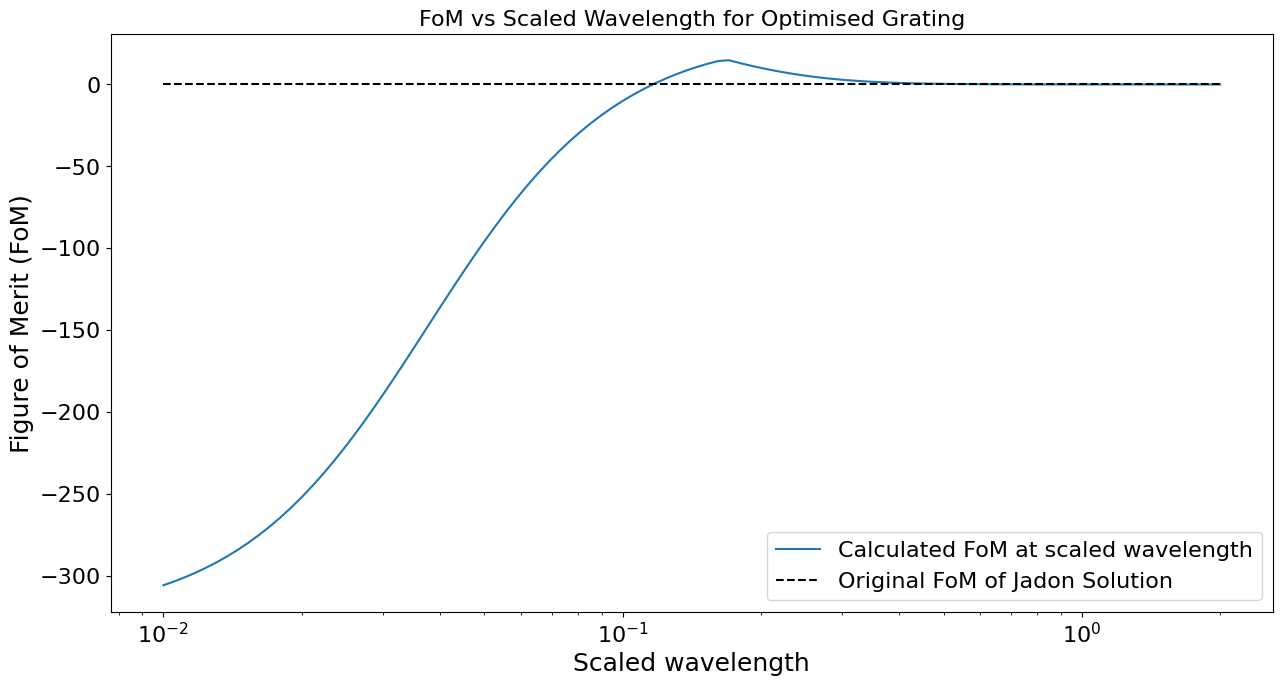

: 

In [ ]:
import matplotlib.pyplot as plt
plt.clf()
plt.semilogx(scales, calc_foms, label='Calculated FoM at scaled wavelength')

plt.plot(scales, np.zeros_like(scales)+actual_fom, 'k--', label='Original FoM of Jadon Solution')
plt.xlabel('Scaled wavelength')
plt.ylabel('Figure of Merit (FoM)')
plt.title('FoM vs Scaled Wavelength for Optimised Grating')
plt.legend()

In [5]:
###################CHECKING FOM EXTRACTION TECHNIQUE#####################################

scaled = 1.000025 # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=scaled, angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

stiffnesses_original = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix
stiffnesses_scaled = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False)

J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_original))
J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses_scaled))


eigReal_o, eigImag_o = fom.Eigs(grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues

eigReal_s, eigImag_s = fom.Eigs(scaled_grating,I0,m,c,grad_method="finite",
                            return_vec = False, normalise=False, use_perturbed=False) # to get eigenvalues


actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

fom_test_s =  scaled_grating.npa.min(-eigReal_s)
fom_test_o = grating.npa.min(-eigReal_o)

fom_actual_o = fom.multifom(grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print(f"\nFoM at scaled wavelength: {actual_fom}")
print(f"\nFoM at unscaled wavelength: {fom_actual_o}")
print(f"\nFoM_test at scaled wavelength: {fom_test_s}")
print(f"\nFoM_test at unscaled wavelength: {fom_test_o}")
print(f"\nDifference (unscaled): {fom_actual_o - fom_test_o}")
print(f"\nDifference (scaled): {actual_fom - fom_test_s}")


FoM at scaled wavelength: 0.014211517059641113

FoM at unscaled wavelength: 0.014213230597554142

FoM_test at scaled wavelength: 0.014214196511955705

FoM_test at unscaled wavelength: 0.014215895183000758

Difference (unscaled): -2.6645854466159774e-06

Difference (scaled): -2.679452314592254e-06
